In [144]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
line_w = 2

### Resistive Circuit

In [69]:
t = np.linspace(0,0.1,1000)
f = 160 # Hz
V = 0.8*np.sin(f*t)
R = 1.5
i = V/R
P = V*i

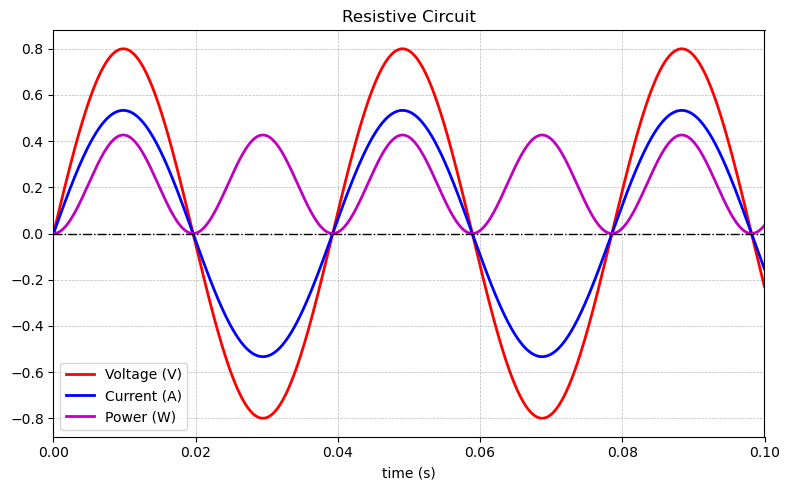

In [70]:
plt.figure(figsize=(8,5))
plt.plot(t,V, color = 'r', label = 'Voltage (V)', linewidth=line_w)
plt.plot(t,i, color = 'b', label = 'Current (A)', linewidth=line_w)
plt.plot(t,P, color = 'm', label = 'Power (W)', linewidth=line_w)
plt.plot(t,np.zeros(len(t)), color = 'k',linestyle = '-.',linewidth=1)
plt.xlim(0,0.1)
plt.xlabel('time (s)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.title('Resistive Circuit')
plt.tight_layout()
plt.legend()
plt.show()

### Resistor - Inductor (RL) Circuit

In [71]:
from IPython.display import display, Math

eq1 = r"V = L \frac{di}{dt}"
eq2 = r"X_L = 2 π f L "
display(Math(eq1))
display(Math(eq2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Reactance: 1.01
Impedance Magnitude: 1.81 Ohms
Impedance Angle: 33.83 Degrees


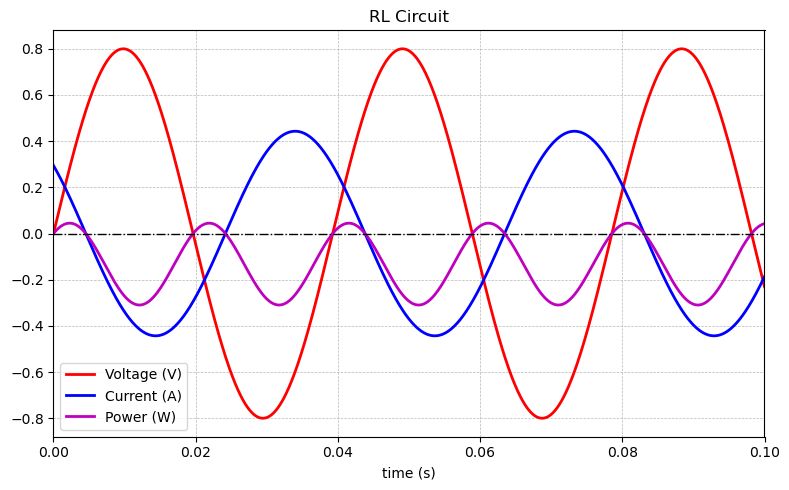

In [75]:
L = 1*10**(-3) #H
X_L = 2*np.pi*f*L
print(f'Reactance: {X_L:.2f}')
# Inductor add 90 degree phase shift
Z = complex(R, X_L)

# Calc Mag of Impedances
Z_mag = np.sqrt(Z.real**2+Z.imag**2) 
# Calc lag and convert to degrees
Z_ang = np.arctan(Z.imag/Z.real)*(180/np.pi)
print(f'Impedance Magnitude: {Z_mag:.2f} Ohms')
print(f'Impedance Angle: {Z_ang:.2f} Degrees')

i = 0.8*np.sin(f*t+Z_ang)/Z_mag
P = V*i

plt.figure(figsize=(8,5))
plt.plot(t,V, color = 'r', label = 'Voltage (V)', linewidth=line_w)
plt.plot(t,i, color = 'b', label = 'Current (A)', linewidth=line_w)
plt.plot(t,P, color = 'm', label = 'Power (W)', linewidth=line_w)
plt.plot(t,np.zeros(len(t)), color = 'k',linestyle = '-.',linewidth=1)
plt.xlim(0,0.1)
plt.xlabel('time (s)')
plt.title('RL Circuit')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.legend()
plt.show()

### Resistor - Capacitor (RC) Circuit

In [76]:
eq1 = r"i = C \frac{dV}{dt}"
eq2 = r"X_C = \frac{1}{2 π f C} "
display(Math(eq1))
display(Math(eq2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Reactance: 0.99
Impedance Magnitude: 1.80 Ohms
Impedance Angle: -33.55 Degrees


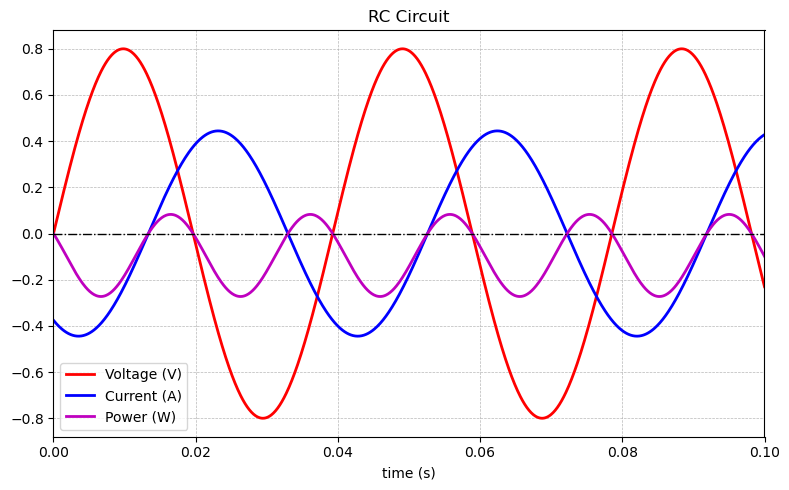

In [78]:
C = 1*10**(-3) #F
X_C = 1/(2*np.pi*f*C)
print(f'Reactance: {X_C:.2f}')
# Inductor add 90 degree phase shift
Z = complex(R, -X_C)

# Calc Mag of Impedances
Z_mag = np.sqrt(Z.real**2+Z.imag**2) 
# Calc lag and convert to degrees
Z_ang = np.arctan(Z.imag/Z.real)*(180/np.pi)
print(f'Impedance Magnitude: {Z_mag:.2f} Ohms')
print(f'Impedance Angle: {Z_ang:.2f} Degrees')

i = 0.8*np.sin(f*t+Z_ang)/Z_mag
P = V*i

plt.figure(figsize=(8,5))
plt.plot(t,V, color = 'r', label = 'Voltage (V)', linewidth=line_w)
plt.plot(t,i, color = 'b', label = 'Current (A)', linewidth=line_w)
plt.plot(t,P, color = 'm', label = 'Power (W)', linewidth=line_w)
plt.plot(t,np.zeros(len(t)), color = 'k',linestyle = '-.',linewidth=1)
plt.xlim(0,0.1)
plt.xlabel('time (s)')
plt.title('RC Circuit')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.legend()
plt.show()

### RLC Series Circuits 

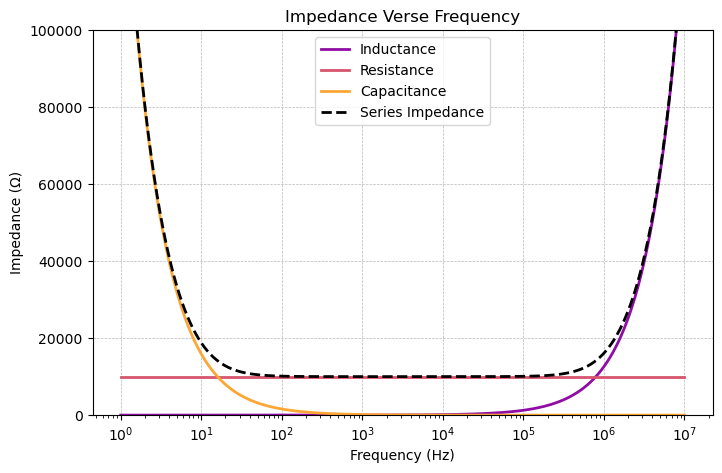

In [124]:
f_sweep = np.logspace(0,7, 1001)
C = 1e-6 #F
L = 2e-3 #H
R = np.full(len(f_sweep), 10e3)
X_C = 1/(2*np.pi*f_sweep*C)
X_L = 2*np.pi*f_sweep*L
Z_mag = np.zeros(len(f_sweep))
Z_ang = np.zeros(len(f_sweep))

for i in range(0, len(f_sweep)):
    Z = complex(R[i], X_L[i]-X_C[i])
    Z_mag[i] = np.sqrt(Z.real**2+Z.imag**2) 
    Z_ang[i] = np.arctan(Z.imag/Z.real)*(180/np.pi)

colors = cm.plasma(np.linspace(0.3, 0.8, 3))
plt.figure(figsize=(8,5))
plt.plot(f_sweep, X_L, color=colors[0], label='Inductance', linewidth=line_w)
plt.plot(f_sweep, R, color=colors[1], label='Resistance', linewidth=line_w)
plt.plot(f_sweep, X_C, color=colors[2], label='Capacitance', linewidth=line_w)
plt.plot(f_sweep, Z_mag, color='k', linestyle='--', label='Series Impedance', linewidth=line_w)
plt.title('Impedance Verse Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.ylabel('Impedance (Ω)')
plt.xlabel('Frequency (Hz)')
plt.ylim(0,1e5)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.legend()
plt.show()

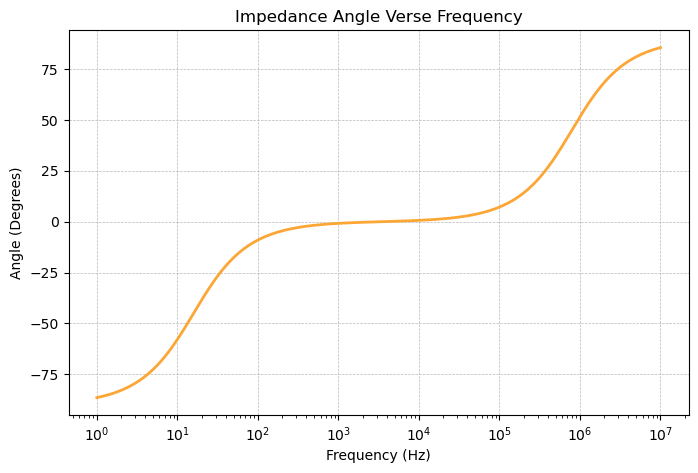

In [126]:
plt.figure(figsize=(8,5))
plt.plot(f_sweep, Z_ang, color=colors[-1], label='Impedance Angle', linewidth=line_w)
plt.title('Impedance Angle Verse Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.ylabel('Angle (Degrees)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.show()

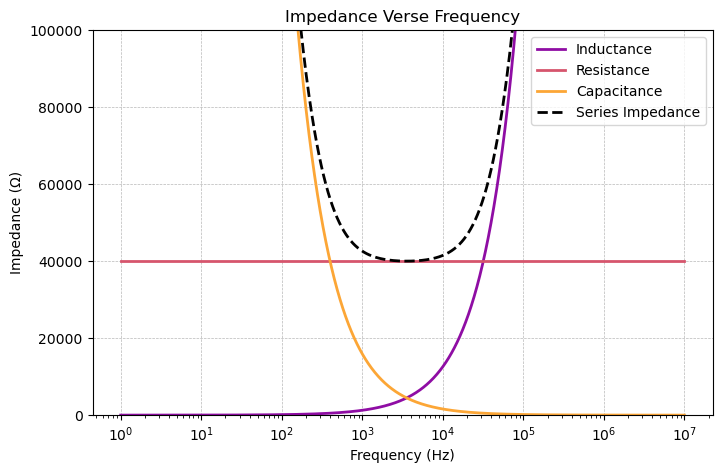

In [134]:
f_sweep = np.logspace(0,7, 1001)
C = .01e-6 #F
L = 200e-3 #H
R = np.full(len(f_sweep), 40e3)
X_C = 1/(2*np.pi*f_sweep*C)
X_L = 2*np.pi*f_sweep*L
Z_mag = np.zeros(len(f_sweep))
Z_ang = np.zeros(len(f_sweep))

for i in range(0, len(f_sweep)):
    Z = complex(R[i], X_L[i]-X_C[i])
    Z_mag[i] = np.sqrt(Z.real**2+Z.imag**2) 
    Z_ang[i] = np.arctan(Z.imag/Z.real)*(180/np.pi)

colors = cm.plasma(np.linspace(0.3, 0.8, 3))
plt.figure(figsize=(8,5))
plt.plot(f_sweep, X_L, color=colors[0], label='Inductance', linewidth=line_w)
plt.plot(f_sweep, R, color=colors[1], label='Resistance', linewidth=line_w)
plt.plot(f_sweep, X_C, color=colors[2], label='Capacitance', linewidth=line_w)
plt.plot(f_sweep, Z_mag, color='k', linestyle='--', label='Series Impedance', linewidth=line_w)
plt.title('Impedance Verse Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.ylabel('Impedance (Ω)')
plt.xlabel('Frequency (Hz)')
plt.ylim(0,1e5)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.legend()
plt.show()

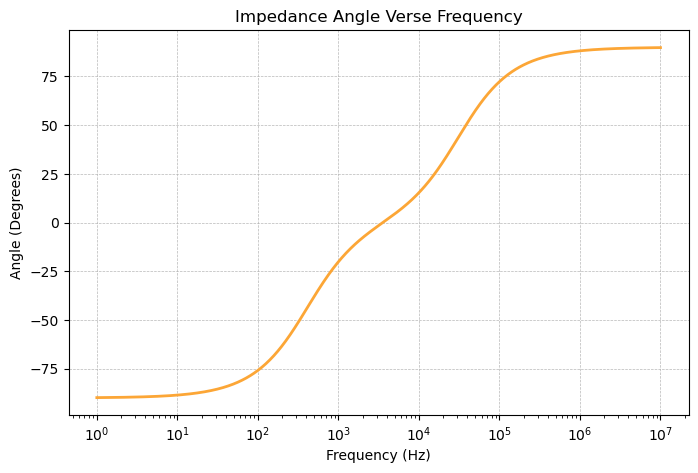

In [135]:
plt.figure(figsize=(8,5))
plt.plot(f_sweep, Z_ang, color=colors[-1], label='Impedance Angle', linewidth=line_w)
plt.title('Impedance Angle Verse Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.ylabel('Angle (Degrees)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
plt.show()

### RLC Tank Circuit

![Tank Image](./img/Tank.jpg)

In [158]:
res = 500
C_sweep = np.logspace(-4,-11,res) # F
L_sweep = np.logspace(-2,-8,res) # H
f_resonance = np.zeros((len(C_sweep),len(L_sweep)))
for i in range(len(C_sweep)):
    for j in range(len(L_sweep)):
        f_resonance[i,j] = 1/(2*np.pi*np.sqrt(L_sweep[j]*C_sweep[i]))

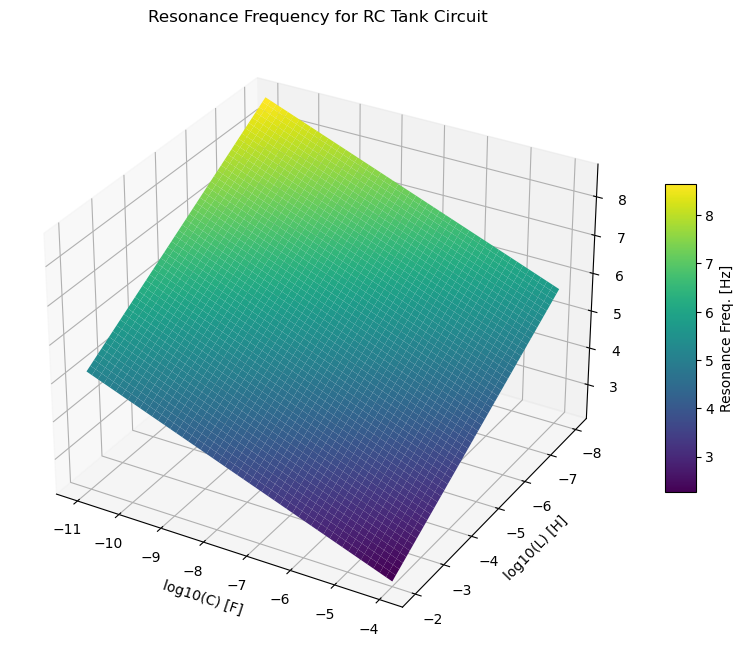

In [160]:
# Create a meshgrid for C and L values to plot
C_mesh, L_mesh = np.meshgrid(C_sweep, L_sweep)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(np.log10(C_mesh), np.log10(L_mesh), np.log10(f_resonance), cmap='viridis')

ax.set_xlabel('log10(C) [F]')
ax.set_ylabel('log10(L) [H]')
# ax.set_zlabel('Resonance Freq. [Hz]')
ax.invert_yaxis()

ax.set_title('Resonance Frequency for RC Tank Circuit')

# Add color bar to the plot
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Resonance Freq. [Hz]')

# Show plot
plt.show()